In [13]:
import os
import json
import joblib
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

path = kagglehub.dataset_download("anshtanwar/current-daily-price-of-various-commodities-india")
print("Path to dataset files:", path)

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path, low_memory=False)
df.head()


Using Colab cache for faster access to the 'current-daily-price-of-various-commodities-india' dataset.
Path to dataset files: /kaggle/input/current-daily-price-of-various-commodities-india


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min Price,Max Price,Modal Price
0,Gujarat,Amreli,Damnagar,Bhindi(Ladies Finger),Bhindi,FAQ,27-07-2023,4100.0,4500.0,4350.0
1,Gujarat,Amreli,Damnagar,Brinjal,Other,FAQ,27-07-2023,2200.0,3000.0,2450.0
2,Gujarat,Amreli,Damnagar,Cabbage,Cabbage,FAQ,27-07-2023,2350.0,3000.0,2700.0
3,Gujarat,Amreli,Damnagar,Cauliflower,Cauliflower,FAQ,27-07-2023,7000.0,7500.0,7250.0
4,Gujarat,Amreli,Damnagar,Coriander(Leaves),Coriander,FAQ,27-07-2023,8400.0,9000.0,8850.0


In [14]:
df.columns = df.columns.astype(str).str.strip().str.replace(" ", "_")
df = df.rename(columns={"Arrival_Date": "Date"})
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

for c in ["Min_Price", "Max_Price", "Modal_Price"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["State", "District", "Market", "Commodity", "Variety", "Grade"]:
    df[c] = df[c].fillna("Unknown").astype(str).str.strip()

df = df.dropna(subset=["Date", "Modal_Price"])
df = df[df["Modal_Price"] > 0]
df = df.sort_values(["Commodity", "Market", "Date"]).reset_index(drop=True)

print(df.shape)
print(df["Date"].min(), df["Date"].max())


(23093, 10)
2023-07-27 00:00:00 2023-08-02 00:00:00


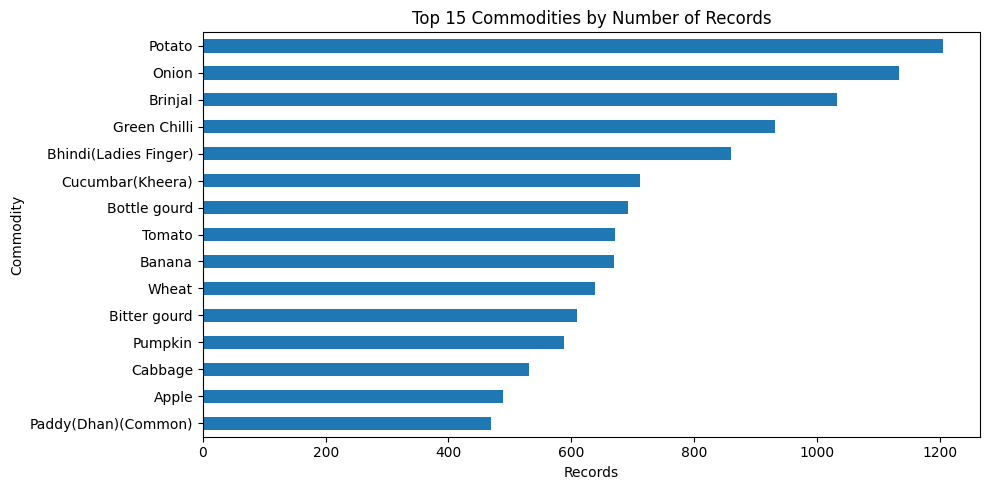

In [15]:
plt.figure(figsize=(10, 5))
df["Commodity"].value_counts().head(15).sort_values().plot(kind="barh")
plt.xlabel("Records")
plt.ylabel("Commodity")
plt.title("Top 15 Commodities by Number of Records")
plt.tight_layout()
plt.show()


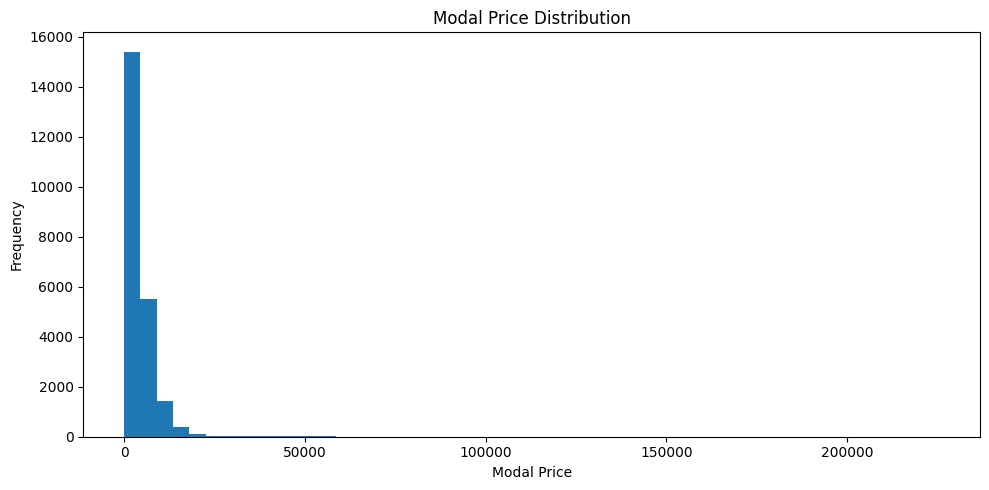

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(df["Modal_Price"], bins=50)
plt.xlabel("Modal Price")
plt.ylabel("Frequency")
plt.title("Modal Price Distribution")
plt.tight_layout()
plt.show()


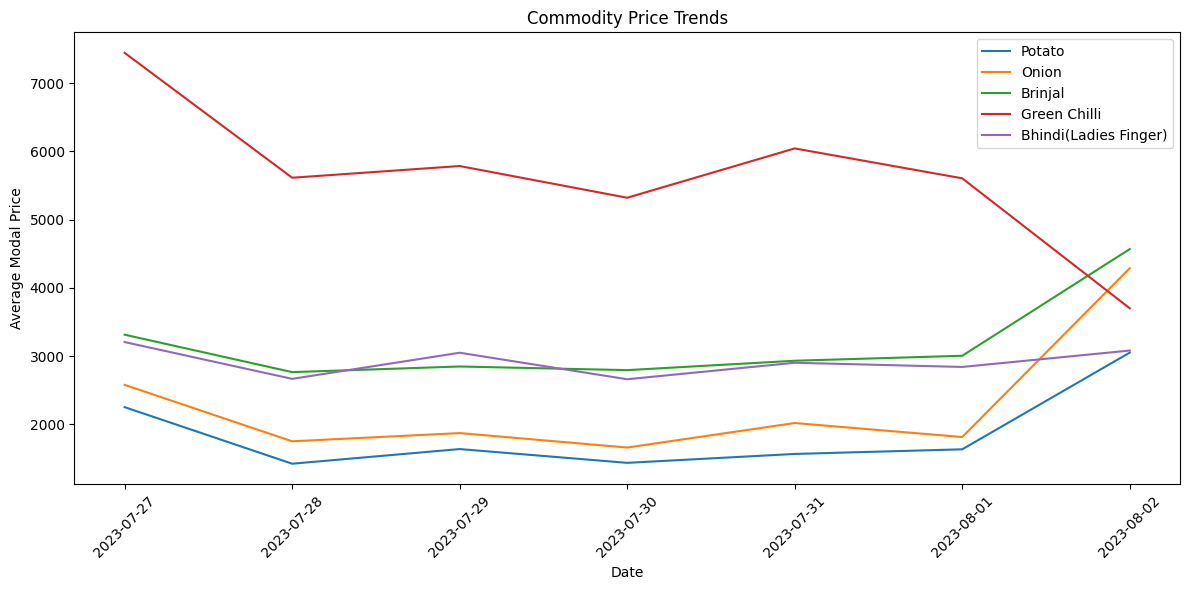

In [17]:
top_commodities = df["Commodity"].value_counts().head(5).index
trend = df[df["Commodity"].isin(top_commodities)].groupby(["Date", "Commodity"])["Modal_Price"].mean().reset_index()

plt.figure(figsize=(12, 6))
for commodity in top_commodities:
    temp = trend[trend["Commodity"] == commodity]
    plt.plot(temp["Date"], temp["Modal_Price"], label=commodity)

plt.xlabel("Date")
plt.ylabel("Average Modal Price")
plt.title("Commodity Price Trends")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


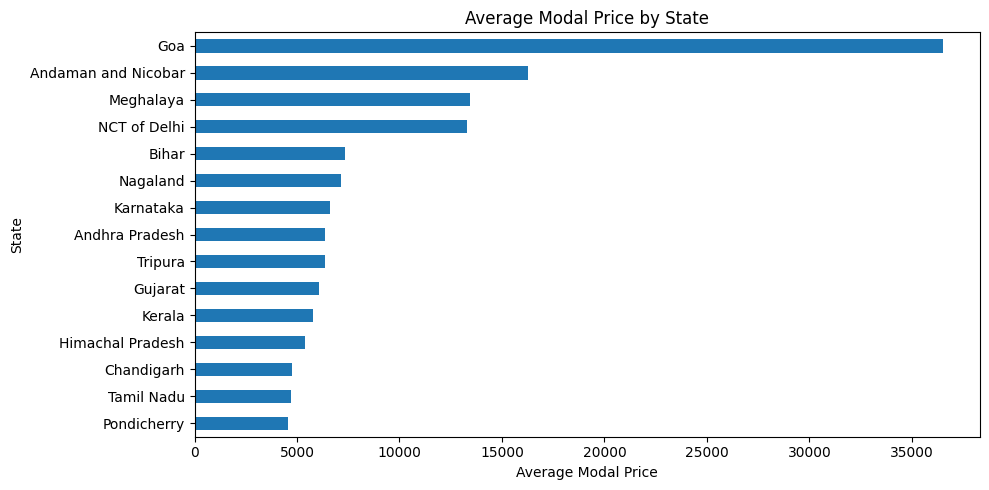

In [18]:
plt.figure(figsize=(10, 5))
df.groupby("State")["Modal_Price"].mean().sort_values(ascending=False).head(15).sort_values().plot(kind="barh")
plt.xlabel("Average Modal Price")
plt.ylabel("State")
plt.title("Average Modal Price by State")
plt.tight_layout()
plt.show()


In [19]:
group = df.groupby(["Commodity", "Market"])

df["lag_1"] = group["Modal_Price"].shift(1)
df["lag_3"] = group["Modal_Price"].shift(3)
df["lag_7"] = group["Modal_Price"].shift(7)

df["rolling_mean_7"] = group["Modal_Price"].transform(
    lambda x: x.shift(1).rolling(7, min_periods=3).mean()
)

df["rolling_std_7"] = group["Modal_Price"].transform(
    lambda x: x.shift(1).rolling(7, min_periods=3).std()
)

df["price_change_1"] = df["lag_1"] - df["lag_3"]
df["month"] = df["Date"].dt.month
df["day_of_week"] = df["Date"].dt.dayofweek
df["day_of_month"] = df["Date"].dt.day

for day in range(1, 8):
    df[f"target_{day}"] = group["Modal_Price"].shift(-day)

df.shape


(23093, 26)

In [20]:
numeric_features = [
    "Min_Price",
    "Max_Price",
    "lag_1",
    "lag_3",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "price_change_1",
    "month",
    "day_of_week",
    "day_of_month"
]

categorical_features = [
    "State",
    "District",
    "Market",
    "Commodity",
    "Variety",
    "Grade"
]

features = numeric_features + categorical_features

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    (
        "numeric",
        SimpleImputer(strategy="median"),
        numeric_features
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", encoder)
        ]),
        categorical_features
    )
])

def create_model():
    return Pipeline([
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=250,
                max_depth=20,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ])


In [21]:
dates = sorted(df["Date"].dropna().unique())

if len(dates) < 2:
    raise ValueError("Not enough unique dates for forecasting")

split_date = dates[int(len(dates) * 0.8)]

models = {}

metrics = {}

for day in range(1, 8):
    target = f"target_{day}"
    data = df.dropna(subset=[target])

    if len(data) < 10:
        continue

    train = data[data["Date"] < split_date]
    test = data[data["Date"] >= split_date]

    if len(train) == 0 or len(test) == 0:
        continue

    model = create_model()
    model.fit(train[features], train[target])

    pred = model.predict(test[features])

    mae = mean_absolute_error(test[target], pred)
    rmse = np.sqrt(mean_squared_error(test[target], pred))
    r2 = r2_score(test[target], pred)

    models[day] = model

    metrics[f"T+{day}"] = {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2)
    }

    print(
        f"T+{day}: "
        f"MAE={mae:.2f}, "
        f"RMSE={rmse:.2f}, "
        f"R2={r2:.4f}"
    )

T+1: MAE=2662.89, RMSE=5565.51, R2=0.7329
T+2: MAE=5221.11, RMSE=10028.22, R2=0.6371
T+3: MAE=7035.13, RMSE=12547.69, R2=0.5705
T+4: MAE=9871.12, RMSE=15994.93, R2=0.3510
T+5: MAE=9854.62, RMSE=16511.10, R2=0.2167
T+6: MAE=6003.66, RMSE=12912.33, R2=0.1762
T+7: MAE=1374.44, RMSE=1466.76, R2=-0.2667


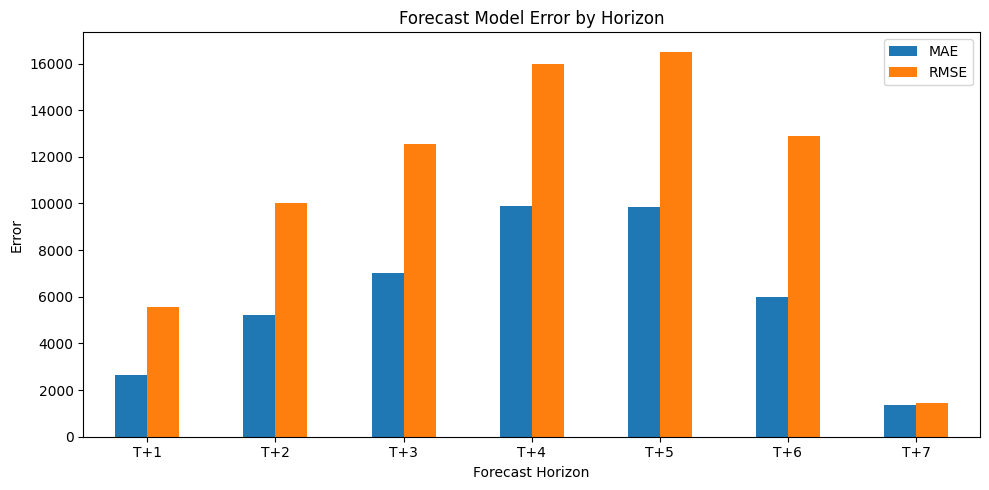

In [22]:
metric_df = pd.DataFrame(metrics).T

metric_df[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Error")
plt.title("Forecast Model Error by Horizon")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [23]:
latest_state = (
    df
    .sort_values(["Commodity", "Market", "Date"])
    .groupby(["Commodity", "Market"])
    .tail(1)
    .reset_index(drop=True)
)

latest_state = latest_state[
    [
        "Date",
        "State",
        "District",
        "Market",
        "Commodity",
        "Variety",
        "Grade",
        "Min_Price",
        "Max_Price",
        "Modal_Price",
        "lag_1",
        "lag_3",
        "lag_7",
        "rolling_mean_7",
        "rolling_std_7",
        "price_change_1",
        "month",
        "day_of_week",
        "day_of_month"
    ]
]

artifact = {
    "models": models,
    "features": features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "forecast_days": 7,
    "metrics": metrics,
    "latest_state": latest_state,
    "price_unit": "INR/quintal"
}

joblib.dump(
    artifact,
    "market_forecast_model.joblib",
    compress=3
)

metadata = {
    "model": "RandomForestRegressor",
    "forecast_days": 7,
    "price_unit": "INR/quintal",
    "crops": sorted(df["Commodity"].unique().tolist()),
    "markets": sorted(df["Market"].unique().tolist()),
    "metrics": metrics,
    "trained_until": str(df["Date"].max().date())
}

with open("market_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("market_forecast_model.joblib")
print("market_metadata.json")


market_forecast_model.joblib
market_metadata.json
